# Electricity Consumption in Spain

## Exploratory Data Analysis, Municipality Analysis and Clustering

## Setup

We use Polars because Table A is large. Lazy Parquet scanning allows us to work with the data without loading all 16 million records into memory at once.

In [1]:
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

In [2]:
# Project root
PROJECT_ROOT = Path.cwd().parent

# Data directories
MAIN_DATA_DIR = PROJECT_ROOT / "export" / "main_parquet"
METADATA_DIR = PROJECT_ROOT / "export" / "small_parquet"
print("Project root:")
print(PROJECT_ROOT)

print("\nMain data directory:")
print(MAIN_DATA_DIR)

print("\nMetadata directory:")
print(METADATA_DIR)

Project root:
e:\tasks\spain_elec

Main data directory:
e:\tasks\spain_elec\export\main_parquet

Metadata directory:
e:\tasks\spain_elec\export\small_parquet


In [3]:
A_PATH = PROJECT_ROOT / "data" / "a.parquet"

if not A_PATH.exists():
    raise FileNotFoundError(
        f"Could not find Table A at: {A_PATH}\n"
        "Make sure the notebook is inside the EDA folder."
    )

# Keep Table A lazy throughout the main analysis.
A_raw = pl.scan_parquet(str(A_PATH))

print("Table A found:", A_PATH)
print("Table A is being read lazily.")

Table A found: e:\tasks\spain_elec\data\a.parquet
Table A is being read lazily.


## Exploring the raw dataset

Before making any assumptions about the variables, I want to see the basic shape of the data: how large it is, what columns exist, and what a few records look like.

In [4]:
raw_schema = A_raw.collect_schema()

A_rows = (
    A_raw
    .select(pl.len())
    .collect()
    .item()
)

print(f"Rows: {A_rows:,}")
print(f"Columns: {len(raw_schema.names())}")

Rows: 16,155,725
Columns: 83


In [5]:
schema_table = pl.DataFrame({
    "column": raw_schema.names(),
    "dtype": [str(dtype) for dtype in raw_schema.dtypes()],
})

schema_table

column,dtype
str,str
"""DIA""","""String"""
"""H1""","""Int32"""
"""ACTIVA_H1""","""Int32"""
"""REACTIVA_H1""","""Int32"""
"""H2""","""Int32"""
…,…
"""TARGET_TENENCIA_CUPS""","""String"""
"""IDENTIFICADOR""","""Int64"""
"""CNAE""","""String"""


In [6]:
A_raw.head(5).collect()

DIA,H1,ACTIVA_H1,REACTIVA_H1,H2,ACTIVA_H2,REACTIVA_H2,H3,ACTIVA_H3,REACTIVA_H3,H4,ACTIVA_H4,REACTIVA_H4,H5,ACTIVA_H5,REACTIVA_H5,H6,ACTIVA_H6,REACTIVA_H6,H7,ACTIVA_H7,REACTIVA_H7,H8,ACTIVA_H8,REACTIVA_H8,H9,ACTIVA_H9,REACTIVA_H9,H10,ACTIVA_H10,REACTIVA_H10,H11,ACTIVA_H11,REACTIVA_H11,H12,ACTIVA_H12,REACTIVA_H12,…,H16,ACTIVA_H16,REACTIVA_H16,H17,ACTIVA_H17,REACTIVA_H17,H18,ACTIVA_H18,REACTIVA_H18,H19,ACTIVA_H19,REACTIVA_H19,H20,ACTIVA_H20,REACTIVA_H20,H21,ACTIVA_H21,REACTIVA_H21,H22,ACTIVA_H22,REACTIVA_H22,H23,ACTIVA_H23,REACTIVA_H23,H24,ACTIVA_H24,REACTIVA_H24,H25,ACTIVA_H25,REACTIVA_H25,DE_MUNICIP,FECHA_ALTA_STRO,TARGET_TENENCIA_CUPS,IDENTIFICADOR,CNAE,PRODUCTO,MERCADO
str,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,str,i64,str,str,str
"""20150624""",1,280,0,2,228,0,3,172,0,4,196,0,5,287,0,6,195,0,7,223,0,8,254,0,9,274,0,10,404,0,11,333,0,12,1106,0,…,16,262,0,17,300,0,18,326,0,19,281,0,20,357,0,21,448,0,22,349,0,23,501,0,24,383,0,25,0,0,"""UBRIQUE""","""Q11989""","""0.127242""",26785,"""T1""","""P1""","""M1"""
"""20150913""",1,142,0,2,61,0,3,67,0,4,64,0,5,64,0,6,70,0,7,126,0,8,101,0,9,40,0,10,179,0,11,131,0,12,169,0,…,16,90,0,17,50,0,18,87,0,19,48,0,20,130,0,21,366,0,22,302,0,23,133,0,24,81,0,25,0,0,"""SANTA COLOMA DE GRAMENET""","""Q31979""","""0.000000""",86782,"""T1""","""P13""","""M2"""
"""20150710""",1,0,0,2,0,0,3,0,0,4,0,0,5,0,0,6,0,0,7,0,0,8,0,0,9,0,0,10,0,0,11,0,0,12,0,0,…,16,0,0,17,0,0,18,0,0,19,0,0,20,0,0,21,0,0,22,0,0,23,0,0,24,0,0,25,0,0,"""VALVERDE""","""Q12010""","""0.000000""",75439,"""T1""","""P14""","""M2"""
"""20150517""",1,186,0,2,129,0,3,176,0,4,123,0,5,183,0,6,200,0,7,185,0,8,170,0,9,161,0,10,409,0,11,399,0,12,351,0,…,16,422,0,17,321,0,18,330,0,19,346,0,20,329,0,21,348,0,22,345,0,23,142,0,24,236,0,25,0,0,"""CAZORLA""","""Q31989""","""0.000000""",43916,"""T1""","""P1""","""M1"""
"""20141108""",1,48,0,2,86,0,3,115,0,4,50,0,5,48,0,6,108,0,7,119,0,8,59,0,9,59,0,10,106,0,11,113,0,12,59,0,…,16,112,0,17,65,0,18,681,0,19,731,0,20,493,0,21,466,0,22,231,0,23,67,0,24,67,0,25,0,0,"""HUELVA""","""Q31989""","""0.011962""",18260,"""T1""","""P1""","""M1"""


The first look shows a wide dataset: each record contains the date, a set of time-position variables, active and reactive electricity measurements, and customer/geographical characteristics.

At this stage I am not treating repeated records or missing values as errors. I first want to understand what one observation represents.

## Making the column names easier to work with

The original column names are useful for tracing the data back to its source, but English names make the analysis easier to read.

The raw Parquet file is **not modified**. The renaming happens only in the LazyFrame used by this notebook.

In [7]:
column_mapping = {
    "DIA": "DATE",
    "DE_MUNICIP": "MUNICIPALITY",
    "FECHA_ALTA_STRO": "SUPPLY_REGISTRATION_PERIOD",
    "TARGET_TENENCIA_CUPS": "GAS_DISTRIBUTION_PROBABILITY",
    "IDENTIFICADOR": "CUSTOMER_ID",
    "CNAE": "CUSTOMER_TYPE",
    "PRODUCTO": "ELECTRICITY_PRODUCT",
    "MERCADO": "MARKET",
}

for i in range(1, 26):
    column_mapping[f"H{i}"] = f"TIME_H{i}"
    column_mapping[f"ACTIVA_H{i}"] = f"ACTIVE_H{i}"
    column_mapping[f"REACTIVA_H{i}"] = f"REACTIVE_H{i}"

A = A_raw.rename(column_mapping)

print("Columns after renaming:")
print(A.collect_schema().names())

Columns after renaming:
['DATE', 'TIME_H1', 'ACTIVE_H1', 'REACTIVE_H1', 'TIME_H2', 'ACTIVE_H2', 'REACTIVE_H2', 'TIME_H3', 'ACTIVE_H3', 'REACTIVE_H3', 'TIME_H4', 'ACTIVE_H4', 'REACTIVE_H4', 'TIME_H5', 'ACTIVE_H5', 'REACTIVE_H5', 'TIME_H6', 'ACTIVE_H6', 'REACTIVE_H6', 'TIME_H7', 'ACTIVE_H7', 'REACTIVE_H7', 'TIME_H8', 'ACTIVE_H8', 'REACTIVE_H8', 'TIME_H9', 'ACTIVE_H9', 'REACTIVE_H9', 'TIME_H10', 'ACTIVE_H10', 'REACTIVE_H10', 'TIME_H11', 'ACTIVE_H11', 'REACTIVE_H11', 'TIME_H12', 'ACTIVE_H12', 'REACTIVE_H12', 'TIME_H13', 'ACTIVE_H13', 'REACTIVE_H13', 'TIME_H14', 'ACTIVE_H14', 'REACTIVE_H14', 'TIME_H15', 'ACTIVE_H15', 'REACTIVE_H15', 'TIME_H16', 'ACTIVE_H16', 'REACTIVE_H16', 'TIME_H17', 'ACTIVE_H17', 'REACTIVE_H17', 'TIME_H18', 'ACTIVE_H18', 'REACTIVE_H18', 'TIME_H19', 'ACTIVE_H19', 'REACTIVE_H19', 'TIME_H20', 'ACTIVE_H20', 'REACTIVE_H20', 'TIME_H21', 'ACTIVE_H21', 'REACTIVE_H21', 'TIME_H22', 'ACTIVE_H22', 'REACTIVE_H22', 'TIME_H23', 'ACTIVE_H23', 'REACTIVE_H23', 'TIME_H24', 'ACTIVE_H24', 'R

The measurement groups now have a consistent naming scheme:

- `ACTIVE_H1` to `ACTIVE_H25` → active electricity measurements
- `REACTIVE_H1` to `REACTIVE_H25` → reactive electricity measurements
- `TIME_H1` to `TIME_H25` → time-position variables

The customer and descriptive fields have also been renamed to make the later analysis more readable.

## Checking Schema Datatypes

In [8]:
schema_table = pl.DataFrame({
    "column": A.collect_schema().names(),
    "dtype": [str(dtype) for dtype in raw_schema.dtypes()],
})

schema_table

column,dtype
str,str
"""DATE""","""String"""
"""TIME_H1""","""Int32"""
"""ACTIVE_H1""","""Int32"""
"""REACTIVE_H1""","""Int32"""
"""TIME_H2""","""Int32"""
…,…
"""GAS_DISTRIBUTION_PROBABILITY""","""String"""
"""CUSTOMER_ID""","""Int64"""
"""CUSTOMER_TYPE""","""String"""


In [9]:
A = A.with_columns(
    pl.col("GAS_DISTRIBUTION_PROBABILITY").cast(pl.Float32, strict=False)
)

In [10]:
A.collect_schema()["GAS_DISTRIBUTION_PROBABILITY"]

Float32

## Understanding the date

The date is currently stored as text. Before doing anything time-related, I will check its range, number of distinct dates, and whether any values fail to convert to a real date.

In [11]:
date_overview = (
    A.select(
        pl.col("DATE").min().alias("first_date_text"),
        pl.col("DATE").max().alias("last_date_text"),
        pl.col("DATE").n_unique().alias("unique_dates"),
        pl.col("DATE").null_count().alias("missing_date_values"),
    )
    .collect()
)

date_overview

first_date_text,last_date_text,unique_dates,missing_date_values
str,str,u32,u32
"""20130913""","""20151019""",727,0


In [12]:
A = A.with_columns(
    pl.col("DATE")
    .str.strptime(
        pl.Date,
        format="%Y%m%d",
        strict=False
    )
    .alias("DATE")
)

date_quality = (
    A.select(
        pl.col("DATE").min().alias("first_date"),
        pl.col("DATE").max().alias("last_date"),
        pl.col("DATE").n_unique().alias("unique_dates"),
        pl.col("DATE").null_count().alias("invalid_or_missing_dates"),
    )
    .collect()
)

date_quality

first_date,last_date,unique_dates,invalid_or_missing_dates
date,date,u32,u32
2013-09-13,2015-10-19,727,0


The converted date will be used throughout the rest of the notebook. Keeping it as a proper date type avoids string-based mistakes when grouping observations by month, year, or season.

## Looking at the time-position variables

There are 25 variables named `TIME_H1` to `TIME_H25`. The documentation associated with the dataset describes the original H1–H25 fields as the hour/time positions within the day.

Rather than simply accepting that description, I will look at the values actually present in Table A.

In [13]:
time_cols = [f"TIME_H{i}" for i in range(1, 26)]

time_unique_counts = (
    A.select([
        pl.col(c).n_unique().alias(c)
        for c in time_cols
    ])
    .collect()
)

time_unique_counts

TIME_H1,TIME_H2,TIME_H3,TIME_H4,TIME_H5,TIME_H6,TIME_H7,TIME_H8,TIME_H9,TIME_H10,TIME_H11,TIME_H12,TIME_H13,TIME_H14,TIME_H15,TIME_H16,TIME_H17,TIME_H18,TIME_H19,TIME_H20,TIME_H21,TIME_H22,TIME_H23,TIME_H24,TIME_H25
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2


In [14]:
A.select(time_cols).head(3).collect()

TIME_H1,TIME_H2,TIME_H3,TIME_H4,TIME_H5,TIME_H6,TIME_H7,TIME_H8,TIME_H9,TIME_H10,TIME_H11,TIME_H12,TIME_H13,TIME_H14,TIME_H15,TIME_H16,TIME_H17,TIME_H18,TIME_H19,TIME_H20,TIME_H21,TIME_H22,TIME_H23,TIME_H24,TIME_H25
i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25


In [15]:
A.select([
    pl.col(c).null_count().alias(c)
    for c in time_cols
]).collect()

TIME_H1,TIME_H2,TIME_H3,TIME_H4,TIME_H5,TIME_H6,TIME_H7,TIME_H8,TIME_H9,TIME_H10,TIME_H11,TIME_H12,TIME_H13,TIME_H14,TIME_H15,TIME_H16,TIME_H17,TIME_H18,TIME_H19,TIME_H20,TIME_H21,TIME_H22,TIME_H23,TIME_H24,TIME_H25
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


The H variables are treated as time-position information rather than electricity measurements. The actual energy values are stored separately in the ACTIVE and REACTIVE groups.

## Looking at active electricity consumption

Active consumption is the main measurement for this project. I will first inspect the individual hourly columns before creating a total daily measure.

At this stage, missing values are being **observed, not automatically deleted or replaced**.

In [16]:
active_cols = [f"ACTIVE_H{i}" for i in range(1, 26)]
reactive_cols = [f"REACTIVE_H{i}" for i in range(1, 26)]

active_stats = []

for c in active_cols:
    row = (
        A.select([
            pl.col(c).count().alias("non_null"),
            pl.col(c).null_count().alias("nulls"),
            pl.col(c).min().alias("minimum"),
            pl.col(c).max().alias("maximum"),
            pl.col(c).mean().alias("mean"),
            pl.col(c).median().alias("median"),
        ])
        .collect()
        .row(0)
    )

    active_stats.append({
        "column": c,
        "non_null": row[0],
        "nulls": row[1],
        "minimum": row[2],
        "maximum": row[3],
        "mean": row[4],
        "median": row[5],
    })

active_stats_df = pl.DataFrame(active_stats)
active_stats_df

column,non_null,nulls,minimum,maximum,mean,median
str,i64,i64,i64,i64,f64,f64
"""ACTIVE_H1""",16155725,0,-712,139194,271.243321,137.0
"""ACTIVE_H2""",16155725,0,-859,129014,219.068148,108.0
"""ACTIVE_H3""",16155725,0,-601,119181,190.031008,96.0
"""ACTIVE_H4""",16155725,0,-787,112334,175.119921,90.0
"""ACTIVE_H5""",16155725,0,-511,110510,169.011393,88.0
…,…,…,…,…,…,…
"""ACTIVE_H21""",16155725,0,-834,150367,407.396173,202.0
"""ACTIVE_H22""",16155725,0,-807,154261,435.502091,233.0
"""ACTIVE_H23""",16155725,0,-950,137113,407.42143,223.0


A useful first observation is whether missingness is concentrated in particular time positions. This matters later because a missing hourly measurement should not automatically be interpreted as a zero measurement.

In [17]:
active_null_summary = (
    A.select([
        pl.col(c).null_count().alias(c)
        for c in active_cols
    ])
    .collect()
)

active_null_summary

ACTIVE_H1,ACTIVE_H2,ACTIVE_H3,ACTIVE_H4,ACTIVE_H5,ACTIVE_H6,ACTIVE_H7,ACTIVE_H8,ACTIVE_H9,ACTIVE_H10,ACTIVE_H11,ACTIVE_H12,ACTIVE_H13,ACTIVE_H14,ACTIVE_H15,ACTIVE_H16,ACTIVE_H17,ACTIVE_H18,ACTIVE_H19,ACTIVE_H20,ACTIVE_H21,ACTIVE_H22,ACTIVE_H23,ACTIVE_H24,ACTIVE_H25
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Looking at reactive consumption

Reactive energy is useful as supporting information, but active energy remains the main measure for the municipality ranking and clustering.

One issue already visible in the supplied data is that reactive values can contain many nulls. I will keep those original nulls rather than changing the raw measurements.

In [18]:
reactive_null_summary = (
    A.select([
        pl.col(c).null_count().alias(c)
        for c in reactive_cols
    ])
    .collect()
)

reactive_null_summary

REACTIVE_H1,REACTIVE_H2,REACTIVE_H3,REACTIVE_H4,REACTIVE_H5,REACTIVE_H6,REACTIVE_H7,REACTIVE_H8,REACTIVE_H9,REACTIVE_H10,REACTIVE_H11,REACTIVE_H12,REACTIVE_H13,REACTIVE_H14,REACTIVE_H15,REACTIVE_H16,REACTIVE_H17,REACTIVE_H18,REACTIVE_H19,REACTIVE_H20,REACTIVE_H21,REACTIVE_H22,REACTIVE_H23,REACTIVE_H24,REACTIVE_H25
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Understanding customers and municipalities

Now I want to understand the observational units. In particular, I want to know how many customers and municipalities are represented and whether the basic identifying fields contain missing values.

In [19]:
customer_geo_overview = (
    A.select([
        pl.col("CUSTOMER_ID").n_unique().alias("unique_customers"),
        pl.col("CUSTOMER_ID").null_count().alias("missing_customer_ids"),
        pl.col("MUNICIPALITY").n_unique().alias("unique_municipalities"),
        pl.col("MUNICIPALITY").null_count().alias("missing_municipalities"),
    ])
    .collect()
)

customer_geo_overview

unique_customers,missing_customer_ids,unique_municipalities,missing_municipalities
u32,u32,u32,u32
100000,0,809,0


In [20]:
A.select("MUNICIPALITY").unique().sort("MUNICIPALITY").head(30).collect()

MUNICIPALITY
str
""""""
"""A CORUÃ‘A"""
"""ABIA DE LAS TORRES"""
"""ABRERA"""
"""ACEBEDO"""
…
"""ALCALA LA REAL"""
"""ALCANAR"""
"""ALCAUDETE"""


In [21]:
A.filter(
    pl.col("MUNICIPALITY") == ""
).collect()

DATE,TIME_H1,ACTIVE_H1,REACTIVE_H1,TIME_H2,ACTIVE_H2,REACTIVE_H2,TIME_H3,ACTIVE_H3,REACTIVE_H3,TIME_H4,ACTIVE_H4,REACTIVE_H4,TIME_H5,ACTIVE_H5,REACTIVE_H5,TIME_H6,ACTIVE_H6,REACTIVE_H6,TIME_H7,ACTIVE_H7,REACTIVE_H7,TIME_H8,ACTIVE_H8,REACTIVE_H8,TIME_H9,ACTIVE_H9,REACTIVE_H9,TIME_H10,ACTIVE_H10,REACTIVE_H10,TIME_H11,ACTIVE_H11,REACTIVE_H11,TIME_H12,ACTIVE_H12,REACTIVE_H12,…,TIME_H16,ACTIVE_H16,REACTIVE_H16,TIME_H17,ACTIVE_H17,REACTIVE_H17,TIME_H18,ACTIVE_H18,REACTIVE_H18,TIME_H19,ACTIVE_H19,REACTIVE_H19,TIME_H20,ACTIVE_H20,REACTIVE_H20,TIME_H21,ACTIVE_H21,REACTIVE_H21,TIME_H22,ACTIVE_H22,REACTIVE_H22,TIME_H23,ACTIVE_H23,REACTIVE_H23,TIME_H24,ACTIVE_H24,REACTIVE_H24,TIME_H25,ACTIVE_H25,REACTIVE_H25,MUNICIPALITY,SUPPLY_REGISTRATION_PERIOD,GAS_DISTRIBUTION_PROBABILITY,CUSTOMER_ID,CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET
date,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,f32,i64,str,str,str
2015-04-06,1,107,0,2,64,0,3,58,0,4,57,0,5,54,0,6,54,1,7,53,0,8,185,12,9,74,9,10,196,4,11,79,9,12,114,3,…,16,117,4,17,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""""","""""",null,0,"""""","""""",""""""


In [22]:
A.filter(
    pl.col("CUSTOMER_ID") == 0
).collect()

DATE,TIME_H1,ACTIVE_H1,REACTIVE_H1,TIME_H2,ACTIVE_H2,REACTIVE_H2,TIME_H3,ACTIVE_H3,REACTIVE_H3,TIME_H4,ACTIVE_H4,REACTIVE_H4,TIME_H5,ACTIVE_H5,REACTIVE_H5,TIME_H6,ACTIVE_H6,REACTIVE_H6,TIME_H7,ACTIVE_H7,REACTIVE_H7,TIME_H8,ACTIVE_H8,REACTIVE_H8,TIME_H9,ACTIVE_H9,REACTIVE_H9,TIME_H10,ACTIVE_H10,REACTIVE_H10,TIME_H11,ACTIVE_H11,REACTIVE_H11,TIME_H12,ACTIVE_H12,REACTIVE_H12,…,TIME_H16,ACTIVE_H16,REACTIVE_H16,TIME_H17,ACTIVE_H17,REACTIVE_H17,TIME_H18,ACTIVE_H18,REACTIVE_H18,TIME_H19,ACTIVE_H19,REACTIVE_H19,TIME_H20,ACTIVE_H20,REACTIVE_H20,TIME_H21,ACTIVE_H21,REACTIVE_H21,TIME_H22,ACTIVE_H22,REACTIVE_H22,TIME_H23,ACTIVE_H23,REACTIVE_H23,TIME_H24,ACTIVE_H24,REACTIVE_H24,TIME_H25,ACTIVE_H25,REACTIVE_H25,MUNICIPALITY,SUPPLY_REGISTRATION_PERIOD,GAS_DISTRIBUTION_PROBABILITY,CUSTOMER_ID,CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET
date,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,f32,i64,str,str,str
2015-04-06,1,107,0,2,64,0,3,58,0,4,57,0,5,54,0,6,54,1,7,53,0,8,185,12,9,74,9,10,196,4,11,79,9,12,114,3,…,16,117,4,17,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""""","""""",null,0,"""""","""""",""""""


In [23]:
A = A.lazy().remove(pl.col("CUSTOMER_ID") == 0)

In [24]:
A.select("MUNICIPALITY").unique().collect()

MUNICIPALITY
str
"""ONDA"""
"""NAVIA"""
"""LASARTE-ORIA"""
"""RUTE"""
"""HERRERIAS"""
…
"""LA BAÃ‘EZA"""
"""RONCAL"""
"""MOLLERUSSA"""


The municipality field will be the key geographic dimension of the project. Later, the customer-level observations will be aggregated into one analytical row per municipality.

## Exploring the categorical variables

The dataset also contains customer type, electricity product, market, registration period, and the gas-distribution probability variable.

At this stage I am interested in their cardinality and actual values, not yet in using them as clustering variables.

In [25]:
categorical_cols = [
    "CUSTOMER_TYPE",
    "ELECTRICITY_PRODUCT",
    "MARKET",
    "SUPPLY_REGISTRATION_PERIOD",
]

A = A.with_columns([
        pl.col(c).replace("", None)
        for c in categorical_cols
    ])

categorical_overview = (
    A.select([
        pl.col(c).n_unique().alias(c)
        for c in categorical_cols
    ])
    .collect()
)

categorical_overview

CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET,SUPPLY_REGISTRATION_PERIOD
u32,u32,u32,u32
2,86,2,171


In [26]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(
        A.select(col)
        .unique()
        .sort(col)
        .head(30)
        .collect()
    )


--- CUSTOMER_TYPE ---
shape: (2, 1)
┌───────────────┐
│ CUSTOMER_TYPE │
│ ---           │
│ str           │
╞═══════════════╡
│ T1            │
│ T2            │
└───────────────┘

--- ELECTRICITY_PRODUCT ---
shape: (30, 1)
┌─────────────────────┐
│ ELECTRICITY_PRODUCT │
│ ---                 │
│ str                 │
╞═════════════════════╡
│ P1                  │
│ P106                │
│ P11                 │
│ P110                │
│ P111                │
│ …                   │
│ P28                 │
│ P29                 │
│ P3                  │
│ P30                 │
│ P31                 │
└─────────────────────┘

--- MARKET ---
shape: (2, 1)
┌────────┐
│ MARKET │
│ ---    │
│ str    │
╞════════╡
│ M1     │
│ M2     │
└────────┘

--- SUPPLY_REGISTRATION_PERIOD ---
shape: (30, 1)
┌────────────────────────────┐
│ SUPPLY_REGISTRATION_PERIOD │
│ ---                        │
│ str                        │
╞════════════════════════════╡
│ null                       │
│ Q11904    

In [27]:
A.select(pl.col("CUSTOMER_TYPE").value_counts(normalize=True)).collect()

CUSTOMER_TYPE
struct[2]
"{""T1"",0.829269}"
"{""T2"",0.170731}"


In [28]:
A.select(pl.col("MARKET").value_counts(normalize=True)).collect()

MARKET
struct[2]
"{""M1"",0.57538}"
"{""M2"",0.42462}"


In [29]:
A.select(pl.col("ELECTRICITY_PRODUCT").value_counts(sort=True,normalize=True)).collect()

ELECTRICITY_PRODUCT
struct[2]
"{""P1"",0.548785}"
"{""P13"",0.177474}"
"{""P30"",0.079511}"
"{""P17"",0.035537}"
"{""P2"",0.021147}"
…
"{""P118"",0.000007}"
"{""P119"",0.000003}"
"{""P95"",0.000002}"


The reference documentation describes `CUSTOMER_TYPE` as the renamed form of the original CNAE field, with T1 representing domestic customers and T2 non-domestic/industrial customers. The market field distinguishes the market categories present in the source data.

These variables can later help explain why municipalities with similar total consumption may still have different consumption structures.

## Inspecting the observational unit

One question needs special attention before cleaning: does one `CUSTOMER_ID + DATE` combination correspond to exactly one record?

If not, simply calling repeated customer-days "duplicates" would be incorrect. I will first measure the structure.

In [30]:
customer_day_counts = (
    A.select(["CUSTOMER_ID", "DATE"])
    .group_by(["CUSTOMER_ID", "DATE"])
    .agg(
        pl.len().alias("records_per_customer_day")
    )
)

customer_day_summary = (
    customer_day_counts
    .select([
        pl.len().alias("unique_customer_days"),
        (pl.col("records_per_customer_day") == 1).sum().alias("one_record"),
        (pl.col("records_per_customer_day") > 1).sum().alias("multiple_records"),
        pl.col("records_per_customer_day").max().alias("maximum_records_per_customer_day"),
    ])
    .collect()
)

customer_day_summary

unique_customer_days,one_record,multiple_records,maximum_records_per_customer_day
u32,u32,u32,u32
15984952,15815820,169132,5


In [31]:
customer_day_frequency = (
    customer_day_counts
    .group_by("records_per_customer_day")
    .agg(
        pl.len().alias("customer_days")
    )
    .sort("records_per_customer_day")
    .collect()
)

customer_day_frequency

records_per_customer_day,customer_days
u32,u32
1,15815820
2,167940
3,746
4,444
5,2


## Checking exact duplicates

There are two different concepts:

- an **exact duplicate** has all variables identical;
- a repeated `CUSTOMER_ID + DATE` may contain different measurements and therefore is not necessarily a duplicate.

I will check exact duplicates separately.

In [32]:
active_cols = [f"ACTIVE_H{i}" for i in range(1, 26)]
multi_keys = customer_day_counts.filter(pl.col("records_per_customer_day") > 1).select(["CUSTOMER_ID", "DATE"])

diagnostic = (
    A.join(multi_keys, on=["CUSTOMER_ID", "DATE"], how="inner")
    .with_columns(
        pl.sum_horizontal([pl.col(c).is_not_null() for c in active_cols]).alias("hours_populated")
    )
    .group_by(["CUSTOMER_ID", "DATE"])
    .agg([
        pl.len().alias("n_records"),
        pl.col("hours_populated").sum().alias("hours_populated_summed_across_records"),
        pl.col("hours_populated").max().alias("hours_populated_in_fullest_record"),
        pl.col("CUSTOMER_TYPE").n_unique().alias("n_distinct_customer_types"),
        pl.col("MARKET").n_unique().alias("n_distinct_markets"),
        pl.col("ELECTRICITY_PRODUCT").n_unique().alias("n_distinct_products"),
        
        # Calculates how many individual hours contain >1 unique, non-null values 
        pl.sum_horizontal([
            (pl.col(c).n_unique() > 1)
            for c in active_cols
        ]).alias("n_conflicting_hours")
    ])
    .collect()
)

diagnostic.select([
    (pl.col("n_distinct_customer_types") > 1).sum().alias("groups_with_customer_type_change"),
    (pl.col("n_distinct_markets") > 1).sum().alias("groups_with_market_change"),
    (pl.col("n_distinct_products") > 1).sum().alias("groups_with_product_change"),
    ((pl.col("hours_populated_summed_across_records") >= 20) &
     (pl.col("hours_populated_in_fullest_record") < 20)).sum().alias("groups_looking_complementary"),
    (pl.col("n_conflicting_hours") > 0).sum().alias("groups_with_conflicting_energy"),
])

groups_with_customer_type_change,groups_with_market_change,groups_with_product_change,groups_looking_complementary,groups_with_conflicting_energy
u32,u32,u32,u32,u32
0,418,418,0,127216


In [33]:
identical_energy_keys = (
    diagnostic.lazy()
    .filter(pl.col("n_conflicting_hours") == 0)
    .select(["CUSTOMER_ID", "DATE"])
)

identical_energy_records = (
    A.join(identical_energy_keys, on=["CUSTOMER_ID", "DATE"], how="inner")
    .sort(["CUSTOMER_ID", "DATE"])
    .head(4)  
    .collect()
)
identical_energy_records

DATE,TIME_H1,ACTIVE_H1,REACTIVE_H1,TIME_H2,ACTIVE_H2,REACTIVE_H2,TIME_H3,ACTIVE_H3,REACTIVE_H3,TIME_H4,ACTIVE_H4,REACTIVE_H4,TIME_H5,ACTIVE_H5,REACTIVE_H5,TIME_H6,ACTIVE_H6,REACTIVE_H6,TIME_H7,ACTIVE_H7,REACTIVE_H7,TIME_H8,ACTIVE_H8,REACTIVE_H8,TIME_H9,ACTIVE_H9,REACTIVE_H9,TIME_H10,ACTIVE_H10,REACTIVE_H10,TIME_H11,ACTIVE_H11,REACTIVE_H11,TIME_H12,ACTIVE_H12,REACTIVE_H12,…,TIME_H16,ACTIVE_H16,REACTIVE_H16,TIME_H17,ACTIVE_H17,REACTIVE_H17,TIME_H18,ACTIVE_H18,REACTIVE_H18,TIME_H19,ACTIVE_H19,REACTIVE_H19,TIME_H20,ACTIVE_H20,REACTIVE_H20,TIME_H21,ACTIVE_H21,REACTIVE_H21,TIME_H22,ACTIVE_H22,REACTIVE_H22,TIME_H23,ACTIVE_H23,REACTIVE_H23,TIME_H24,ACTIVE_H24,REACTIVE_H24,TIME_H25,ACTIVE_H25,REACTIVE_H25,MUNICIPALITY,SUPPLY_REGISTRATION_PERIOD,GAS_DISTRIBUTION_PROBABILITY,CUSTOMER_ID,CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET
date,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,f32,i64,str,str,str
2015-01-25,1,0,0,2,0,0,3,0,0,4,0,0,5,0,0,6,0,0,7,0,0,8,0,0,9,0,0,10,0,0,11,0,0,12,0,0,…,16,0,0,17,0,0,18,0,0,19,0,0,20,0,0,21,0,0,22,0,0,23,0,0,24,0,0,25,0,0,"""A CORUÃ‘A""","""Q22013""",null,2,"""T2""","""P2""","""M1"""
2015-01-25,1,0,0,2,0,0,3,0,0,4,0,0,5,0,0,6,0,0,7,0,0,8,0,0,9,0,0,10,0,0,11,0,0,12,0,0,…,16,0,0,17,0,0,18,0,0,19,0,0,20,0,0,21,0,0,22,0,0,23,0,0,24,0,0,25,0,0,"""A CORUÃ‘A""","""Q22013""",null,2,"""T2""","""P2""","""M1"""
2015-05-21,1,72,0,2,47,0,3,47,0,4,48,0,5,47,0,6,56,0,7,65,0,8,108,0,9,111,0,10,101,0,11,74,0,12,58,0,…,16,74,0,17,67,0,18,58,0,19,102,0,20,73,0,21,86,0,22,50,0,23,53,0,24,64,0,25,0,0,"""SANT BOI DE LLOBREGAT""","""Q21975""",0.6,9,"""T2""","""P1""","""M1"""
2015-05-21,1,72,0,2,47,0,3,47,0,4,48,0,5,47,0,6,56,0,7,65,0,8,108,0,9,111,0,10,101,0,11,74,0,12,58,0,…,16,74,0,17,67,0,18,58,0,19,102,0,20,73,0,21,86,0,22,50,0,23,53,0,24,64,0,25,0,0,"""SANT BOI DE LLOBREGAT""","""Q21975""",0.6,9,"""T2""","""P1""","""M1"""


In [34]:
rows_to_deduplicate = (
    A.join(identical_energy_keys, on=["CUSTOMER_ID", "DATE"], how="inner")
    .select(pl.len())
    .collect()
    .item()
)
print(f"Raw duplicated rows with consistent energy: {rows_to_deduplicate}")

Raw duplicated rows with consistent energy: 84717


In [35]:
# Mark the (CUSTOMER_ID, DATE) groups we are going to collapse
groups_to_collapse = identical_energy_keys.with_columns(
    pl.lit(True).alias("_collapse")
)

# Keep only one record per collapsing group.
# We use an in-group row index so that "first" is well defined and
# every other row of A is left exactly as it was.
A = (
    A
    .with_columns(
        pl.int_range(pl.len())
          .over(["CUSTOMER_ID", "DATE"])
          .alias("_row_in_group")
    )
    .join(
        groups_to_collapse,
        on=["CUSTOMER_ID", "DATE"],
        how="left"
    )
    .filter(
        pl.col("_collapse").is_null()
        | (pl.col("_row_in_group") == 0)
    )
    .drop(["_row_in_group", "_collapse"])
)

In [36]:
n_collapsing_groups = (
    identical_energy_keys.select(pl.len()).collect().item()
)
rows_removed = rows_to_deduplicate - n_collapsing_groups

print(f"Collapsing groups:        {n_collapsing_groups:,}")
print(f"Rows removed:             {rows_removed:,}")
print(f"Rows remaining (lazy):    "
      f"{A.select(pl.len()).collect().item():,}")

# Sanity check: no collapsing group should still contain >1 row.
remaining_dupes = (
    A
    .filter(pl.col("CUSTOMER_ID").is_not_null())
    .group_by(["CUSTOMER_ID", "DATE"])
    .agg(pl.len().alias("n"))
    .filter(pl.col("n") > 1)
    .select(pl.len())
    .collect()
    .item()
)
print(f"Groups still with >1 row: {remaining_dupes:,}")

Collapsing groups:        41,916
Rows removed:             42,801
Rows remaining (lazy):    16,112,923
Groups still with >1 row: 127,216


Repeated customer-days are therefore treated as a structural property that needs to be understood, rather than automatically removed as duplicates.

## Inspecting data quality

Now that the variables and observational structure are clearer, I can inspect the dataset for actual quality problems.

I will not automatically remove unusual values just because they look unusual.

In [37]:
# Missing values across the complete table
all_cols = A.collect_schema().names()

null_summary = (
    A.select([
        pl.col(c).null_count().alias(c)
        for c in all_cols
    ])
    .collect()
    .transpose(
        include_header=True,
        header_name="column",
        column_names=["null_count"]
    )
    .with_columns(
        (pl.col("null_count") / A_rows * 100).alias("null_percent")
    )
    .sort("null_count", descending=True)
)

null_summary

column,null_count,null_percent
str,u32,f64
"""GAS_DISTRIBUTION_PROBABILITY""",4111951,25.451974
"""SUPPLY_REGISTRATION_PERIOD""",340491,2.107556
"""DATE""",0,0.0
"""TIME_H1""",0,0.0
"""ACTIVE_H1""",0,0.0
…,…,…
"""MUNICIPALITY""",0,0.0
"""CUSTOMER_ID""",0,0.0
"""CUSTOMER_TYPE""",0,0.0


The missing-value table lets us distinguish fields with substantial missingness from fields that are effectively complete. In particular, missing hourly electricity measurements are not handled in the same way as missing customer or municipality identifiers.

## Checking invalid dates and essential identifiers

In [38]:
essential_quality = (
    A.select([
        pl.len().alias("rows"),
        pl.col("DATE").null_count().alias("invalid_dates"),
        pl.col("CUSTOMER_ID").null_count().alias("missing_customer_id"),
        pl.col("MUNICIPALITY").null_count().alias("missing_municipality"),
    ])
    .collect()
)

essential_quality

rows,invalid_dates,missing_customer_id,missing_municipality
u32,u32,u32,u32
16112923,0,0,0


## Checking negative consumption

Negative active-energy values deserve investigation. They may be errors, corrections, or another feature of the source data.

For now, I only measure them.

In [39]:
negative_by_hour = (
    A.select([
        (pl.col(c) < 0).sum().alias(c)
        for c in active_cols
    ])
    .collect()
)

negative_by_hour

ACTIVE_H1,ACTIVE_H2,ACTIVE_H3,ACTIVE_H4,ACTIVE_H5,ACTIVE_H6,ACTIVE_H7,ACTIVE_H8,ACTIVE_H9,ACTIVE_H10,ACTIVE_H11,ACTIVE_H12,ACTIVE_H13,ACTIVE_H14,ACTIVE_H15,ACTIVE_H16,ACTIVE_H17,ACTIVE_H18,ACTIVE_H19,ACTIVE_H20,ACTIVE_H21,ACTIVE_H22,ACTIVE_H23,ACTIVE_H24,ACTIVE_H25
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
286,277,264,255,244,260,274,268,287,283,289,277,286,292,278,286,288,280,309,277,271,286,277,308,0


In [40]:
negative_rows = (
    A
    .filter(
        pl.any_horizontal([
            pl.col(c) < 0
            for c in active_cols
        ])
    )
    .select(pl.len())
    .collect()
    .item()
)

print(f"Rows with at least one negative active value: {negative_rows:,}")

Rows with at least one negative active value: 780


Negative values should not be silently deleted. If they are present, their magnitude and frequency should be considered before deciding how they affect the final municipality results.

In [41]:
main_active_cols = [f"ACTIVE_H{i}" for i in range(1, 25)]
negative_summary = (
    A
    .filter(
        pl.any_horizontal([
            pl.col(c) < 0
            for c in main_active_cols
        ])
    )
    .select([
        pl.len().alias("affected_rows"),
        pl.sum_horizontal([
            pl.col(c)
            for c in main_active_cols
        ]).sum().alias("signed_total_consumption_of_affected_rows"),
    ])
    .collect()
)

negative_summary

affected_rows,signed_total_consumption_of_affected_rows
u32,i32
780,2330834


In [42]:
negative_hourly_contribution = (
    A
    .select([
        pl.when(pl.col(c) < 0)
        .then(pl.col(c))
        .otherwise(0)
        .sum()
        .alias(c)
        for c in main_active_cols
    ])
    .collect()
)

negative_hourly_contribution

ACTIVE_H1,ACTIVE_H2,ACTIVE_H3,ACTIVE_H4,ACTIVE_H5,ACTIVE_H6,ACTIVE_H7,ACTIVE_H8,ACTIVE_H9,ACTIVE_H10,ACTIVE_H11,ACTIVE_H12,ACTIVE_H13,ACTIVE_H14,ACTIVE_H15,ACTIVE_H16,ACTIVE_H17,ACTIVE_H18,ACTIVE_H19,ACTIVE_H20,ACTIVE_H21,ACTIVE_H22,ACTIVE_H23,ACTIVE_H24
i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
-12671,-15279,-10103,-9776,-7957,-8738,-10996,-7352,-11534,-8340,-8608,-7510,-12807,-19841,-15697,-18154,-15783,-14892,-22339,-16424,-19075,-23392,-19390,-25566


In [43]:
A = A.with_columns(
    pl.sum_horizontal([
        pl.col(c)
        for c in active_cols
    ]).alias("DAILY_ACTIVE_CONSUMPTION")
)


negative_readings = A.filter(pl.col("DAILY_ACTIVE_CONSUMPTION") < 0)

negative_summary = (
    negative_readings
    .group_by("MUNICIPALITY")
    .agg([
        pl.len().alias("negative_record_count"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").sum().alias("total_negative_volume"),
        pl.col("CUSTOMER_ID").n_unique().alias("unique_affected_customers"),
        pl.col("DATE").min().alias("first_negative_date"),
        pl.col("DATE").max().alias("last_negative_date"),
    ])
    .sort("total_negative_volume") 
    .collect()
)

negative_summary

MUNICIPALITY,negative_record_count,total_negative_volume,unique_affected_customers,first_negative_date,last_negative_date
str,u32,i32,u32,date,date
"""A CORUÃ‘A""",3,-13732,3,2015-05-30,2015-06-11
"""MADRID""",80,-13103,47,2015-02-17,2015-06-06
"""VIGO""",10,-8446,2,2015-02-28,2015-04-16
"""GANDIA""",28,-5831,20,2015-02-17,2015-05-14
"""SAN JAVIER""",21,-4226,13,2015-03-20,2015-04-27
…,…,…,…,…,…
"""OURENSE""",1,-56,1,2015-08-17,2015-08-17
"""DENIA""",3,-33,1,2015-04-08,2015-04-14
"""SANTAS MARTAS""",1,-24,1,2015-03-22,2015-03-22


In [44]:
negative_summary['first_negative_date'].dt.min()

datetime.date(2015, 2, 5)

In [45]:
negative_summary['last_negative_date'].dt.max()

datetime.date(2015, 8, 17)

For the mid-2015 negative values, the fact that they are tightly constrained to a 4-month window (February to June) across completely distinct geographical regions (from Galicia to Valencia) points to a systematic utility event rather than localized hardware failures.

Here are the most probable causes in electrical load datasets:

- Smart Meter Deployment Glitches: A specific batch of meters deployed in early 2015 may have been installed with inverted polarity (wired backward). This causes the meter to count down instead of up. The short timeline indicates technicians caught the error and replaced or rewired them by the summer.

- Spring Net-Metering Artifacts: February through June correlates with rapidly increasing solar irradiance. If this small cohort of customers installed residential solar but the utility had not yet upgraded them to proper bi-directional meters, spring overproduction feeding back into the grid would register as negative baseline consumption.

- Retroactive Batch Corrections: Utilities frequently run automated reconciliation scripts to balance out estimated winter billing. A script deployed in Q1/Q2 2015 to credit over-billed accounts would inject discrete negative values directly into the daily consumption logs.

In [46]:
A = A.with_columns([
    pl.when(pl.col(c) < 0).then(0).otherwise(pl.col(c)).alias(c)
    for c in active_cols
]).with_columns(
    pl.sum_horizontal([
        pl.col(c).cast(pl.Int64) for c in active_cols
    ]).alias("DAILY_ACTIVE_CONSUMPTION")
)

## Adding Latitude Longitude Municipality Coordinates

In [47]:
coordinates = pl.read_csv(r"../BD_MUNICIPIOS-ENTIDADES/DE_MUNICIP_LAT_LONG.csv")
coordinates.head()

,DE_MUNICIP_org,DE_MUNICIP,PROVINCE,LONGITUDE,LATITUDE
i64,str,str,str,f64,f64
0,"""A CORUÃ‘A""","""A CORUÑA""","""A Coruña""",-8.395826,43.371495
1,"""ABIA DE LAS TORRES""","""ABIA DE LAS TORRES""","""Palencia""",-4.421902,42.42022
2,"""ABRERA""","""ABRERA""","""Barcelona""",1.901569,41.516398
3,"""ACEBEDO""","""ACEBEDO""","""León""",-5.115871,43.040732
4,"""ACEUCHAL""","""ACEUCHAL""","""Badajoz""",-6.487251,38.647755


In [48]:
coordinates.schema

Schema([('', Int64),
        ('DE_MUNICIP_org', String),
        ('DE_MUNICIP', String),
        ('PROVINCE', String),
        ('LONGITUDE', Float64),
        ('LATITUDE', Float64)])

In [49]:
coordinates.shape

(817, 6)

In [50]:
duplicates = coordinates.filter(pl.col("DE_MUNICIP_org").is_duplicated())
duplicates

,DE_MUNICIP_org,DE_MUNICIP,PROVINCE,LONGITUDE,LATITUDE
i64,str,str,str,f64,f64
131,"""CABANES""","""CABANES""","""Castelló/Castellón""",0.045412,40.156104
132,"""CABANES""","""CABANES""","""Girona""",2.977957,42.307504
199,"""CIEZA""","""CIEZA""","""Murcia""",-1.42773,38.236594
200,"""CIEZA""","""CIEZA""","""Cantabria""",-4.096722,43.221056
340,"""LA CONCHA""","""VILLAESCUSA""","""Zamora""",-5.464099,41.206136
…,…,…,…,…,…
721,"""TORRENT""","""TORRENT""","""Girona""",3.128197,41.951843
773,"""VILLAESCUSA""","""VILLAESCUSA""","""Zamora""",-5.464099,41.206136
774,"""VILLAESCUSA""","""VILLAESCUSA""","""Cantabria""",-3.856639,43.370333


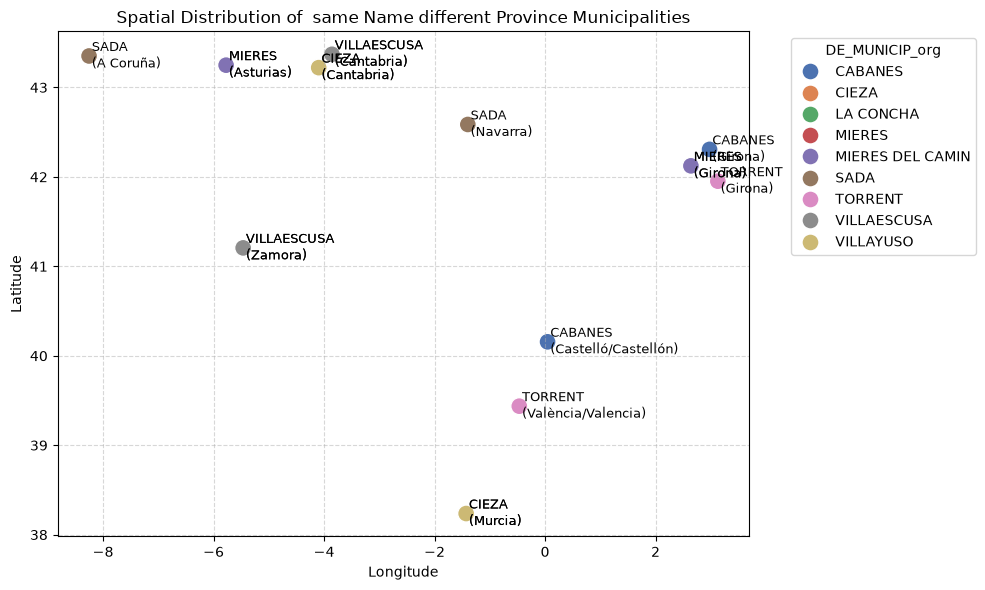

In [51]:
df_plot = duplicates.to_pandas()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_plot,
    x="LONGITUDE",
    y="LATITUDE",
    hue="DE_MUNICIP_org",
    s=150,           
    palette="deep"   
)

for _, row in df_plot.iterrows():
    label = f"{row['DE_MUNICIP']}\n({row['PROVINCE']})"
    plt.text(
        x=row["LONGITUDE"] + 0.05,
        y=row["LATITUDE"], 
        s=label,
        fontsize=9,
        verticalalignment='center'
    )

plt.title("Spatial Distribution of  same Name different Province Municipalities")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend(title="DE_MUNICIP_org", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [52]:
coordinates_clean = coordinates.unique(
    subset=["DE_MUNICIP_org"], 
    keep="last"
)

coordinates_clean = coordinates_clean.select([
    "DE_MUNICIP_org", 
    "LATITUDE", 
    "LONGITUDE", 
    "PROVINCE"
])
coordinates_clean.shape

(808, 4)

In [53]:
A = A.join(
    coordinates_clean.lazy(),
    left_on="MUNICIPALITY",
    right_on="DE_MUNICIP_org",
    how="left",
    suffix="_coords"
)
A.head(3).collect()

DATE,TIME_H1,ACTIVE_H1,REACTIVE_H1,TIME_H2,ACTIVE_H2,REACTIVE_H2,TIME_H3,ACTIVE_H3,REACTIVE_H3,TIME_H4,ACTIVE_H4,REACTIVE_H4,TIME_H5,ACTIVE_H5,REACTIVE_H5,TIME_H6,ACTIVE_H6,REACTIVE_H6,TIME_H7,ACTIVE_H7,REACTIVE_H7,TIME_H8,ACTIVE_H8,REACTIVE_H8,TIME_H9,ACTIVE_H9,REACTIVE_H9,TIME_H10,ACTIVE_H10,REACTIVE_H10,TIME_H11,ACTIVE_H11,REACTIVE_H11,TIME_H12,ACTIVE_H12,REACTIVE_H12,…,ACTIVE_H17,REACTIVE_H17,TIME_H18,ACTIVE_H18,REACTIVE_H18,TIME_H19,ACTIVE_H19,REACTIVE_H19,TIME_H20,ACTIVE_H20,REACTIVE_H20,TIME_H21,ACTIVE_H21,REACTIVE_H21,TIME_H22,ACTIVE_H22,REACTIVE_H22,TIME_H23,ACTIVE_H23,REACTIVE_H23,TIME_H24,ACTIVE_H24,REACTIVE_H24,TIME_H25,ACTIVE_H25,REACTIVE_H25,MUNICIPALITY,SUPPLY_REGISTRATION_PERIOD,GAS_DISTRIBUTION_PROBABILITY,CUSTOMER_ID,CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET,DAILY_ACTIVE_CONSUMPTION,LATITUDE,LONGITUDE,PROVINCE
date,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,f32,i64,str,str,str,i64,f64,f64,str
2015-06-24,1,280,0,2,228,0,3,172,0,4,196,0,5,287,0,6,195,0,7,223,0,8,254,0,9,274,0,10,404,0,11,333,0,12,1106,0,…,300,0,18,326,0,19,281,0,20,357,0,21,448,0,22,349,0,23,501,0,24,383,0,25,0,0,"""UBRIQUE""","""Q11989""",0.127242,26785,"""T1""","""P1""","""M1""",9756,36.677457,-5.443138,"""Cádiz"""
2015-09-13,1,142,0,2,61,0,3,67,0,4,64,0,5,64,0,6,70,0,7,126,0,8,101,0,9,40,0,10,179,0,11,131,0,12,169,0,…,50,0,18,87,0,19,48,0,20,130,0,21,366,0,22,302,0,23,133,0,24,81,0,25,0,0,"""SANTA COLOMA DE GRAMENET""","""Q31979""",0.0,86782,"""T1""","""P13""","""M2""",2957,41.452234,2.207883,"""Barcelona"""
2015-07-10,1,0,0,2,0,0,3,0,0,4,0,0,5,0,0,6,0,0,7,0,0,8,0,0,9,0,0,10,0,0,11,0,0,12,0,0,…,0,0,18,0,0,19,0,0,20,0,0,21,0,0,22,0,0,23,0,0,24,0,0,25,0,0,"""VALVERDE""","""Q12010""",0.0,75439,"""T1""","""P14""","""M2""",0,27.806864,-17.914962,"""Santa Cruz de Tenerife"""


In [54]:
summer_months = [6, 7, 8, 9, 10]
A = A.with_columns(
        pl.when(pl.col("DATE").dt.month().is_in(summer_months))
        .then(pl.lit("Summer"))
        .otherwise(pl.lit("Winter"))
        .alias("Season")
    )

A.head(3).collect()

DATE,TIME_H1,ACTIVE_H1,REACTIVE_H1,TIME_H2,ACTIVE_H2,REACTIVE_H2,TIME_H3,ACTIVE_H3,REACTIVE_H3,TIME_H4,ACTIVE_H4,REACTIVE_H4,TIME_H5,ACTIVE_H5,REACTIVE_H5,TIME_H6,ACTIVE_H6,REACTIVE_H6,TIME_H7,ACTIVE_H7,REACTIVE_H7,TIME_H8,ACTIVE_H8,REACTIVE_H8,TIME_H9,ACTIVE_H9,REACTIVE_H9,TIME_H10,ACTIVE_H10,REACTIVE_H10,TIME_H11,ACTIVE_H11,REACTIVE_H11,TIME_H12,ACTIVE_H12,REACTIVE_H12,…,REACTIVE_H17,TIME_H18,ACTIVE_H18,REACTIVE_H18,TIME_H19,ACTIVE_H19,REACTIVE_H19,TIME_H20,ACTIVE_H20,REACTIVE_H20,TIME_H21,ACTIVE_H21,REACTIVE_H21,TIME_H22,ACTIVE_H22,REACTIVE_H22,TIME_H23,ACTIVE_H23,REACTIVE_H23,TIME_H24,ACTIVE_H24,REACTIVE_H24,TIME_H25,ACTIVE_H25,REACTIVE_H25,MUNICIPALITY,SUPPLY_REGISTRATION_PERIOD,GAS_DISTRIBUTION_PROBABILITY,CUSTOMER_ID,CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET,DAILY_ACTIVE_CONSUMPTION,LATITUDE,LONGITUDE,PROVINCE,Season
date,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,f32,i64,str,str,str,i64,f64,f64,str,str
2015-06-24,1,280,0,2,228,0,3,172,0,4,196,0,5,287,0,6,195,0,7,223,0,8,254,0,9,274,0,10,404,0,11,333,0,12,1106,0,…,0,18,326,0,19,281,0,20,357,0,21,448,0,22,349,0,23,501,0,24,383,0,25,0,0,"""UBRIQUE""","""Q11989""",0.127242,26785,"""T1""","""P1""","""M1""",9756,36.677457,-5.443138,"""Cádiz""","""Summer"""
2015-09-13,1,142,0,2,61,0,3,67,0,4,64,0,5,64,0,6,70,0,7,126,0,8,101,0,9,40,0,10,179,0,11,131,0,12,169,0,…,0,18,87,0,19,48,0,20,130,0,21,366,0,22,302,0,23,133,0,24,81,0,25,0,0,"""SANTA COLOMA DE GRAMENET""","""Q31979""",0.0,86782,"""T1""","""P13""","""M2""",2957,41.452234,2.207883,"""Barcelona""","""Summer"""
2015-07-10,1,0,0,2,0,0,3,0,0,4,0,0,5,0,0,6,0,0,7,0,0,8,0,0,9,0,0,10,0,0,11,0,0,12,0,0,…,0,18,0,0,19,0,0,20,0,0,21,0,0,22,0,0,23,0,0,24,0,0,25,0,0,"""VALVERDE""","""Q12010""",0.0,75439,"""T1""","""P14""","""M2""",0,27.806864,-17.914962,"""Santa Cruz de Tenerife""","""Summer"""


## Visualizations

Before aggregating municipalities, it is useful to see how consumption is distributed at the observation level.

The histogram below uses a sample for visualization. The calculations themselves use the complete dataset.

In [55]:
consumption_overview = (
    A
    .select([
        pl.col("DAILY_ACTIVE_CONSUMPTION").count().alias("non_null"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").min().alias("minimum"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").max().alias("maximum"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").mean().alias("mean"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").median().alias("median"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").quantile(0.01).alias("p01"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").quantile(0.25).alias("p25"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").quantile(0.75).alias("p75"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").quantile(0.99).alias("p99"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").quantile(0.999).alias("p999"),
        (pl.col("DAILY_ACTIVE_CONSUMPTION") == 0).sum().alias("zero_consumption_rows"),
    ])
    .collect()
)

consumption_overview

non_null,minimum,maximum,mean,median,p01,p25,p75,p99,p999,zero_consumption_rows
u32,i64,i64,f64,f64,f64,f64,f64,f64,f64,u32
16112923,0,8215549,7229.175819,4956.0,0.0,1949.0,8853.0,48489.0,125948.0,1661889


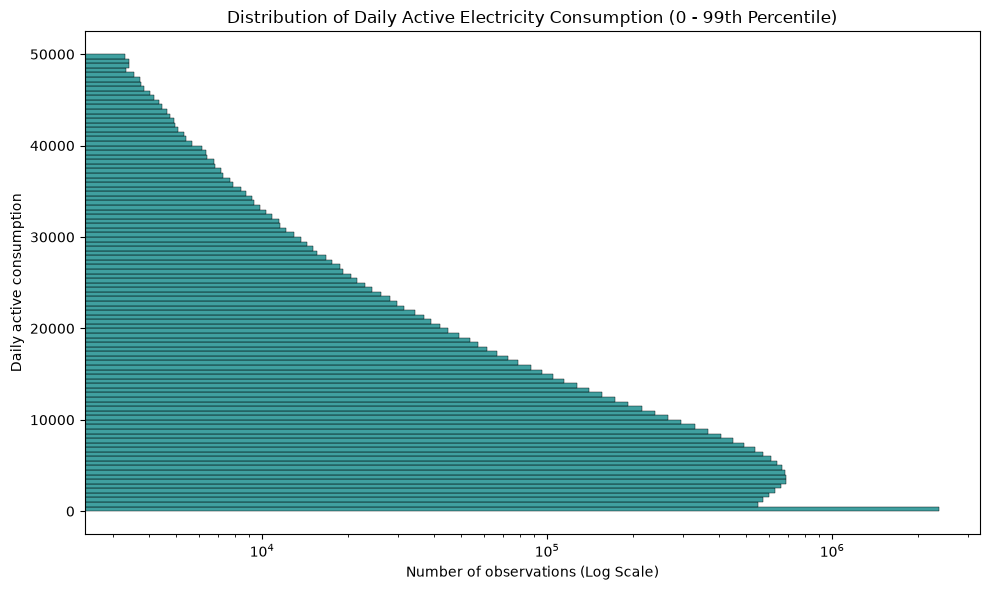

In [56]:
values = (
    A.filter(
        pl.col("DAILY_ACTIVE_CONSUMPTION").is_between(0, 50000)
    )
    .select("DAILY_ACTIVE_CONSUMPTION")
    .collect()
    .to_series()
    .to_numpy()
)

plt.figure(figsize=(10, 6))

sns.histplot(y=values, bins=100, color="teal")

plt.xscale("log") 

plt.ylabel("Daily active consumption")
plt.xlabel("Number of observations (Log Scale)")
plt.title("Distribution of Daily Active Electricity Consumption (0 - 99th Percentile)")

plt.tight_layout()
plt.show()

The distribution is expected to be right-skewed in electricity-consumption data, with many relatively small observations and a smaller number of high-consumption observations. The exact shape and extreme values will guide later feature transformations.

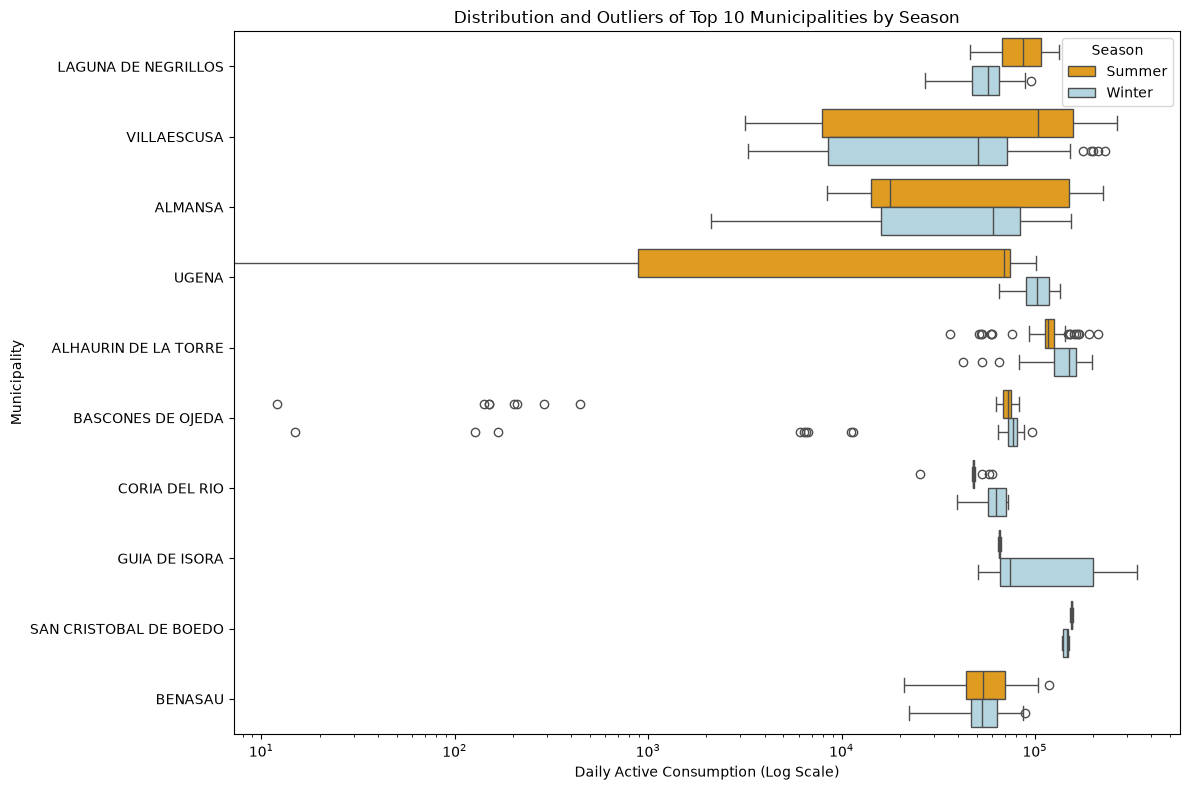

In [57]:
top_10_muni = (
    A.group_by("MUNICIPALITY")
    .agg(pl.col("DAILY_ACTIVE_CONSUMPTION").mean())
    .sort("DAILY_ACTIVE_CONSUMPTION", descending=True)
    .head(10)
    .select("MUNICIPALITY")
    .collect()
    .to_series()
    .to_list()
)

df_plot = (
    A.filter(pl.col("MUNICIPALITY").is_in(top_10_muni))
    .select(["MUNICIPALITY", "Season", "DAILY_ACTIVE_CONSUMPTION"])
    .collect()
    .to_pandas() 
)

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_plot,
    x="DAILY_ACTIVE_CONSUMPTION",
    y="MUNICIPALITY",
    hue="Season",
    palette={"Summer": "orange", "Winter": "lightblue"},
    showfliers=True # Toggle to False to hide the extreme black outlier diamonds
)

plt.xscale("log") # Keeps the boxes visible despite extreme outliers
plt.title("Distribution and Outliers of Top 10 Municipalities by Season")
plt.xlabel("Daily Active Consumption (Log Scale)")
plt.ylabel("Municipality")
plt.tight_layout()
plt.show()

## Inspecting extreme observations

Rather than removing outliers immediately, I want to see the largest observations and where they occur.

In [58]:
largest_observations = (
    A
    .select([
        "CUSTOMER_ID",
        "DATE",
        "MUNICIPALITY",
        "CUSTOMER_TYPE",
        "MARKET",
        "DAILY_ACTIVE_CONSUMPTION",
    ])
    .sort("DAILY_ACTIVE_CONSUMPTION", descending=True)
    .head(20)
    .collect()
)

largest_observations

CUSTOMER_ID,DATE,MUNICIPALITY,CUSTOMER_TYPE,MARKET,DAILY_ACTIVE_CONSUMPTION
i64,date,str,str,str,i64
67072,2015-07-23,"""CASTELLON DE LA PLANA""","""T1""","""M2""",8215549
11933,2015-01-11,"""MADRID""","""T2""","""M2""",2481732
10745,2015-02-24,"""MADRID""","""T2""","""M2""",1473964
10618,2015-02-28,"""MADRID""","""T2""","""M2""",1213811
10618,2015-03-01,"""MADRID""","""T2""","""M2""",1112687
…,…,…,…,…,…
14181,2015-08-24,"""ESPARTINAS""","""T2""","""M2""",843205
14181,2015-08-17,"""ESPARTINAS""","""T2""","""M2""",822845
14181,2015-09-27,"""ESPARTINAS""","""T2""","""M2""",817946


This inspection helps determine whether extreme values are isolated observations, concentrated in particular customer categories, or associated with particular municipalities. Extreme values will not be deleted merely because they are large.

## Exploring electricity consumption over time

Now we can move from individual observations to the overall temporal pattern.

The daily aggregation shows how much active electricity consumption is represented in Table A on each date.

In [59]:
daily_consumption = (
    A
    .group_by("DATE")
    .agg([
        pl.col("DAILY_ACTIVE_CONSUMPTION").sum().alias("total_consumption"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").mean().alias("mean_consumption"),
        pl.col("CUSTOMER_ID").n_unique().alias("customers"),
        pl.len().alias("observations"),
    ])
    .sort("DATE")
    .collect()
)

daily_consumption.head()

DATE,total_consumption,mean_consumption,customers,observations
date,i64,f64,u32,u32
2013-09-13,2441,2441.0,1,1
2013-09-14,2633,2633.0,1,1
2013-09-15,2672,2672.0,1,1
2013-09-16,2571,2571.0,1,1
2013-09-17,2472,2472.0,1,1


In [60]:
daily_consumption.tail()

DATE,total_consumption,mean_consumption,customers,observations
date,i64,f64,u32,u32
2015-10-15,14408174,5604.112797,2571,2571
2015-10-16,3283869,5895.635548,557,557
2015-10-17,3304719,6404.494186,516,516
2015-10-18,3214941,6341.106509,507,507
2015-10-19,35718,3571.8,10,10


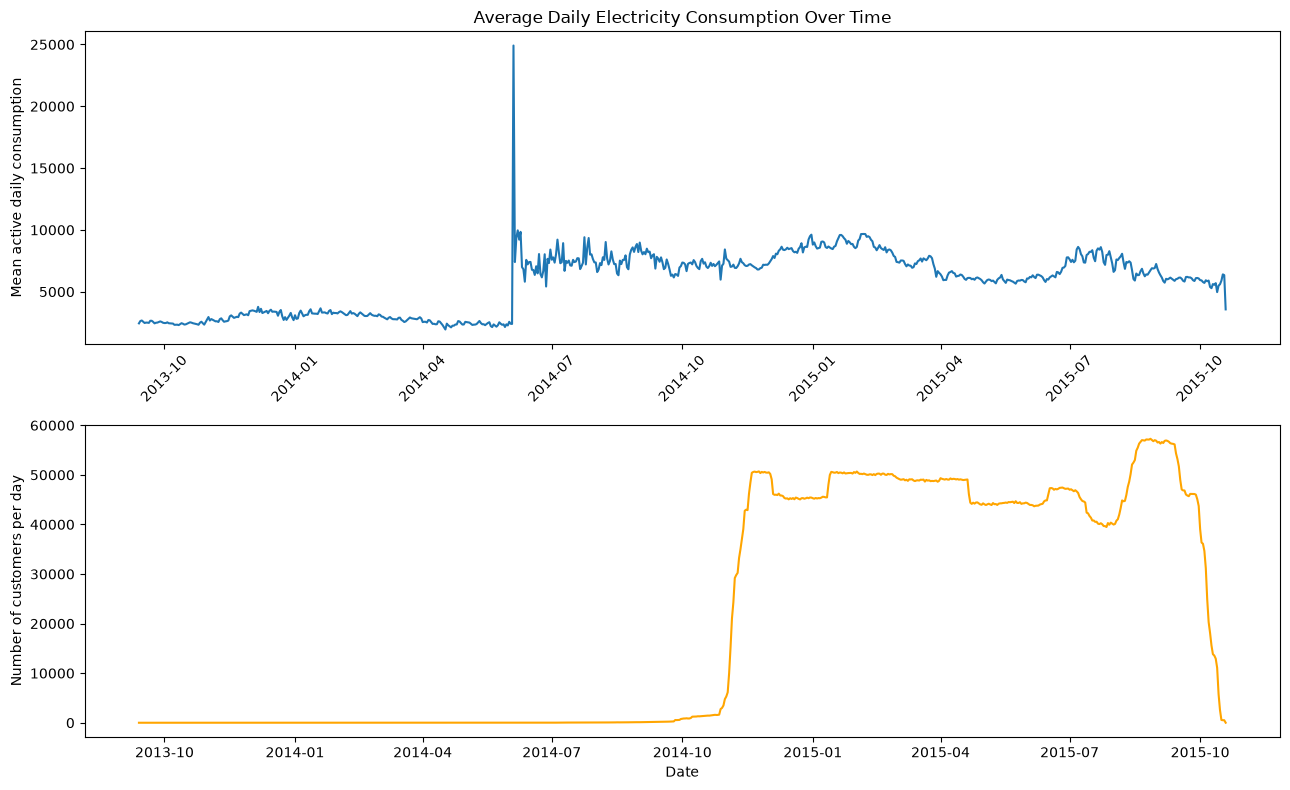

In [61]:
plt.figure(figsize=(13, 8))
plt.subplot(2,1,1)
plt.plot(
    daily_consumption["DATE"].to_numpy(),
    daily_consumption["mean_consumption"].to_numpy(),
)
plt.ylabel("Mean active daily consumption")
plt.title("Average Daily Electricity Consumption Over Time")
plt.xticks(rotation=45)
plt.subplot(2,1,2)
plt.plot(
    daily_consumption["DATE"].to_numpy(),
    daily_consumption["customers"].to_numpy(),
    c='orange'
)
plt.ylabel("Number of customers per day")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [62]:
spike_investigation = (
    daily_consumption.lazy()
    .sort("mean_consumption", descending=True)
    .head(5)
    .collect()
)
print(spike_investigation)

shape: (5, 5)
┌────────────┬───────────────────┬──────────────────┬───────────┬──────────────┐
│ DATE       ┆ total_consumption ┆ mean_consumption ┆ customers ┆ observations │
│ ---        ┆ ---               ┆ ---              ┆ ---       ┆ ---          │
│ date       ┆ i64               ┆ f64              ┆ u32       ┆ u32          │
╞════════════╪═══════════════════╪══════════════════╪═══════════╪══════════════╡
│ 2014-06-04 ┆ 24913             ┆ 24913.0          ┆ 1         ┆ 1            │
│ 2014-06-07 ┆ 29887             ┆ 9962.333333      ┆ 3         ┆ 3            │
│ 2014-06-09 ┆ 49214             ┆ 9842.8           ┆ 5         ┆ 5            │
│ 2015-02-06 ┆ 489345329         ┆ 9672.385535      ┆ 50266     ┆ 50592        │
│ 2015-02-05 ┆ 487831132         ┆ 9666.722124      ┆ 50150     ┆ 50465        │
└────────────┴───────────────────┴──────────────────┴───────────┴──────────────┘


The total daily series should always be interpreted together with the number of customers and observations. A change in the total may reflect a real consumption pattern, a change in coverage, or both.

## Looking at the hourly consumption profile

The 25 active-energy columns can also be examined as a general load profile.

This gives a first idea of whether consumption is concentrated at particular positions in the day.

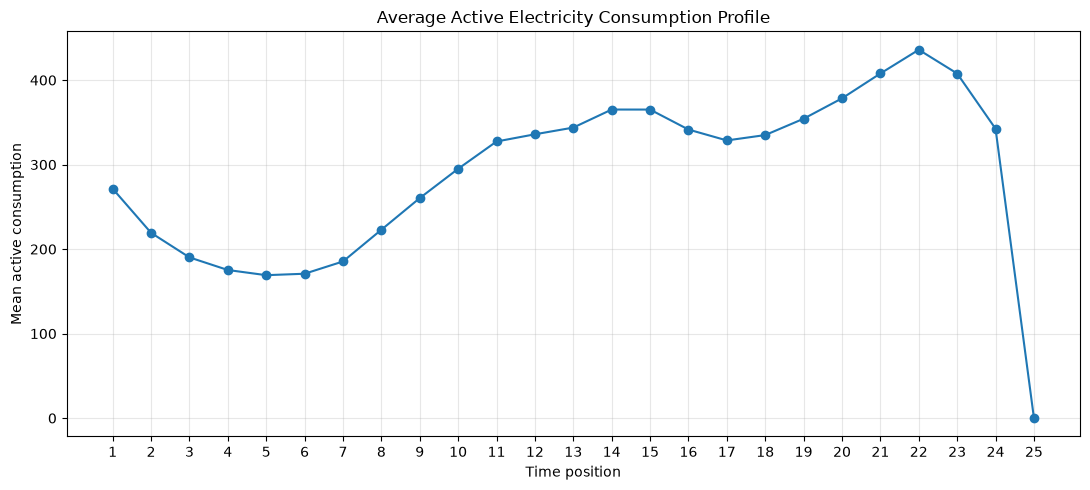

In [63]:
agg_exprs = []
for c in active_cols:
    agg_exprs.append(pl.col(c).mean().alias(f"{c}_mean"))
    agg_exprs.append(pl.col(c).median().alias(f"{c}_median"))

result = A.select(agg_exprs).collect()

# Reshape to long format
hourly_profile = pl.DataFrame({
    "time_position": list(range(1, 26)),
    "mean_consumption": [result[0, f"{c}_mean"] for c in active_cols],
    "median_consumption": [result[0, f"{c}_median"] for c in active_cols],
})

plt.figure(figsize=(11, 5))
plt.plot(
    hourly_profile["time_position"].to_numpy(),
    hourly_profile["mean_consumption"].to_numpy(),
    marker="o"
)
plt.xlabel("Time position")
plt.ylabel("Mean active consumption")
plt.title("Average Active Electricity Consumption Profile")
plt.xticks(range(1, 26))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The shape of this profile will later be useful when comparing municipalities. Municipalities can have similar total consumption while having different daily load shapes.

## Exploring the municipalities

We can now answer the first major project question.

First, I will aggregate the observed active consumption by municipality.

In [64]:
municipality_totals = (
    A
    .group_by("MUNICIPALITY")
    .agg([
        pl.col("DAILY_ACTIVE_CONSUMPTION")
          .cast(pl.Int64)
          .sum()
          .alias("TOTAL_CONSUMPTION"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").mean().alias("MEAN_OBSERVATION_CONSUMPTION"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").median().alias("MEDIAN_OBSERVATION_CONSUMPTION"),
        pl.col("CUSTOMER_ID").n_unique().alias("CUSTOMERS"),
        pl.len().alias("OBSERVATIONS"),
        pl.col("DATE").n_unique().alias("OBSERVED_DAYS"),
    ])
    .with_columns([
        (pl.col("TOTAL_CONSUMPTION") / pl.col("CUSTOMERS")).alias("CONSUMPTION_PER_CUSTOMER"),
        (pl.col("OBSERVATIONS") / pl.col("CUSTOMERS")).alias("OBSERVATIONS_PER_CUSTOMER"),
    ])
    .sort("TOTAL_CONSUMPTION", descending=True)
    .collect()
)

municipality_totals.head(20)


MUNICIPALITY,TOTAL_CONSUMPTION,MEAN_OBSERVATION_CONSUMPTION,MEDIAN_OBSERVATION_CONSUMPTION,CUSTOMERS,OBSERVATIONS,OBSERVED_DAYS,CONSUMPTION_PER_CUSTOMER,OBSERVATIONS_PER_CUSTOMER
str,i64,f64,f64,u32,u32,u32,f64,f64
"""MADRID""",8421376036,7290.224762,4991.0,7478,1155160,503,1.1262e6,154.474458
"""SANT BOI DE LLOBREGAT""",5039789041,7466.520057,5709.0,4156,674985,355,1.2127e6,162.412175
"""RUBI""",4069913893,7313.162521,5529.0,3540,556519,365,1.1497e6,157.208757
"""MAIRENA DEL ALCOR""",3932067932,8520.652109,6241.0,2773,461475,349,1.4180e6,166.417238
"""L'HOSPITALET DE LLOBREGAT""",3556887362,5576.186034,4138.0,4047,637871,366,878894.826291,157.615765
…,…,…,…,…,…,…,…,…
"""UBRIQUE""",1639094148,6082.79454,4683.0,1666,269464,355,983850.028812,161.743097
"""ALBACETE""",1602028739,9455.904162,6055.0,958,169421,376,1.6723e6,176.848643
"""PEÃ‘ARROYA-PUEBLONUEVO""",1574012259,7957.474149,5177.0,1253,197803,347,1.2562e6,157.863528


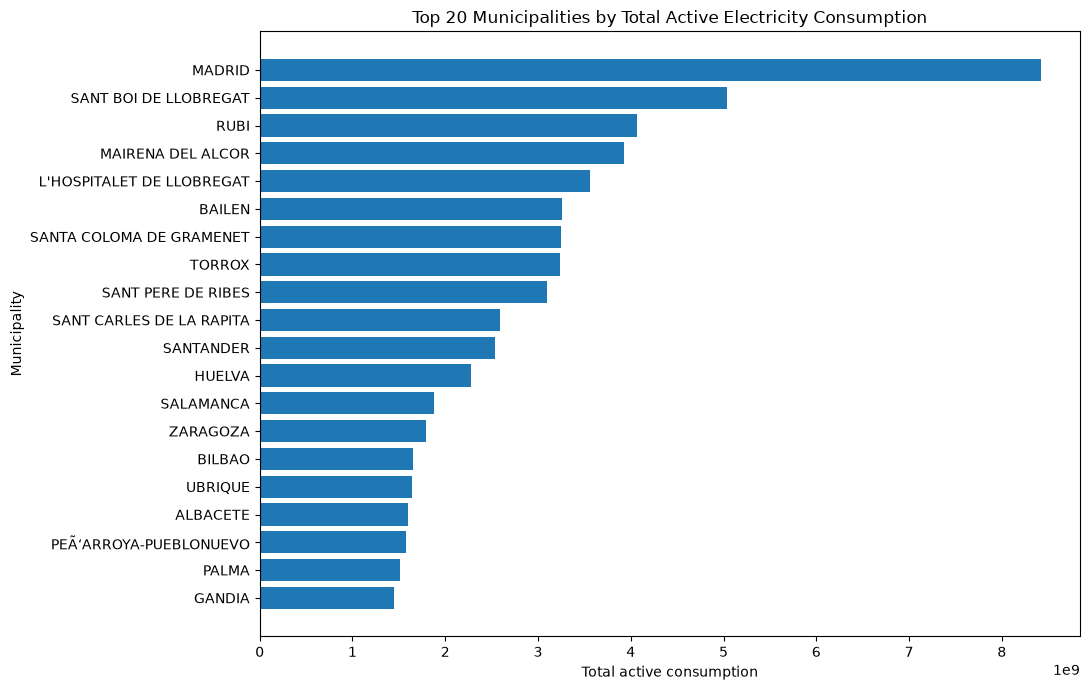

In [65]:
top_20 = municipality_totals.head(20)
plt.figure(figsize=(11, 7))
plt.barh(
    top_20["MUNICIPALITY"].to_list()[::-1],
    top_20["TOTAL_CONSUMPTION"].to_list()[::-1]
)
plt.xlabel("Total active consumption")
plt.ylabel("Municipality")
plt.title("Top 20 Municipalities by Total Active Electricity Consumption")
plt.tight_layout()
plt.show()

## Total consumption versus consumption per customer

A municipality can rank highly simply because it has many customers.

To avoid confusing municipality size with customer-level consumption, I also examine consumption per customer.

In [66]:
top_per_customer = (
    municipality_totals
    .sort("CONSUMPTION_PER_CUSTOMER", descending=True)
    .head(20)
)

top_per_customer

MUNICIPALITY,TOTAL_CONSUMPTION,MEAN_OBSERVATION_CONSUMPTION,MEDIAN_OBSERVATION_CONSUMPTION,CUSTOMERS,OBSERVATIONS,OBSERVED_DAYS,CONSUMPTION_PER_CUSTOMER,OBSERVATIONS_PER_CUSTOMER
str,i64,f64,f64,u32,u32,u32,f64,f64
"""ALHAURIN DE LA TORRE""",45460997,133708.814706,127898.5,1,340,335,4.5460997e7,340.0
"""RODA DE ANDALUCIA (LA)""",42752073,52520.974201,58890.0,3,814,329,1.4250691e7,271.333333
"""PEDRERA""",26454884,48809.749077,63937.5,2,542,312,1.3227442e7,271.0
"""LA SERNA""",13149374,39369.383234,38124.5,1,334,334,1.3149374e7,334.0
"""PILOÃ‘A""",11848342,51966.412281,54403.0,1,228,216,1.1848342e7,228.0
…,…,…,…,…,…,…,…,…
"""MONFERO""",7654192,27732.57971,27960.5,1,276,242,7.654192e6,276.0
"""ESPARTINAS""",60319807,33160.971413,10429.0,8,1819,345,7.5400e6,227.375
"""VALDEVIMBRE""",7311240,25211.172414,19783.0,1,290,238,7.31124e6,290.0


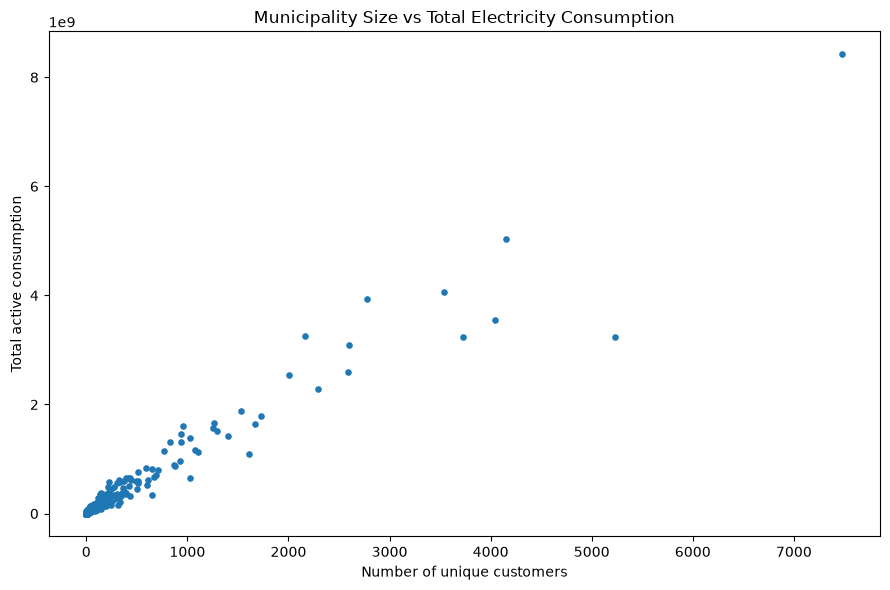

In [67]:
plt.figure(figsize=(9, 6))
plt.scatter(
    municipality_totals["CUSTOMERS"].to_numpy(),
    municipality_totals["TOTAL_CONSUMPTION"].to_numpy(),
    s=14
)
plt.xlabel("Number of unique customers")
plt.ylabel("Total active consumption")
plt.title("Municipality Size vs Total Electricity Consumption")
plt.tight_layout()
plt.show()

This distinction is important for the final report:

- **total consumption** identifies municipalities with the largest aggregate electricity use;
- **consumption per customer** provides a different view of consumption intensity.

Both measures can be useful for understanding the municipality landscape.

## Monthly municipality patterns

Total consumption tells us how large a municipality's electricity use is, but it does not tell us how stable that consumption is over time.

I will therefore build a municipality-by-month table.

In [68]:
A_monthly = A.with_columns(
    pl.col("DATE").dt.strftime("%Y-%m").alias("MONTH")
)

municipality_monthly = (
    A_monthly
    .group_by(["MUNICIPALITY", "MONTH"])
    .agg(
        pl.col("DAILY_ACTIVE_CONSUMPTION")
        .sum()
        .alias("MONTHLY_CONSUMPTION")
    )
    .sort(["MUNICIPALITY", "MONTH"])
    .collect()
)

municipality_monthly.head()

MUNICIPALITY,MONTH,MONTHLY_CONSUMPTION
str,str,i64
"""A CORUÃ‘A""","""2013-09""",43222
"""A CORUÃ‘A""","""2013-10""",50905
"""A CORUÃ‘A""","""2013-11""",78069
"""A CORUÃ‘A""","""2013-12""",88333
"""A CORUÃ‘A""","""2014-01""",91083


## Customer characteristics and municipality composition

Municipalities can have different consumption patterns because their customer populations are different.

I will therefore inspect the customer-type and market composition of the observations.

In [69]:
customer_type_distribution = (
    A
    .group_by("CUSTOMER_TYPE")
    .agg([
        pl.len().alias("OBSERVATIONS"),
        pl.col("CUSTOMER_ID").n_unique().alias("CUSTOMERS"),
        pl.col("MUNICIPALITY").n_unique().alias("MUNICIPALITIES"),
    ])
    .sort("OBSERVATIONS", descending=True)
    .collect()
)

customer_type_distribution

CUSTOMER_TYPE,OBSERVATIONS,CUSTOMERS,MUNICIPALITIES
str,u32,u32,u32
"""T1""",13362420,83002,741
"""T2""",2750503,16997,528


In [70]:
market_distribution = (
    A
    .group_by("MARKET")
    .agg([
        pl.len().alias("OBSERVATIONS"),
        pl.col("CUSTOMER_ID").n_unique().alias("CUSTOMERS"),
        pl.col("MUNICIPALITY").n_unique().alias("MUNICIPALITIES"),
    ])
    .sort("OBSERVATIONS", descending=True)
    .collect()
)

market_distribution

MARKET,OBSERVATIONS,CUSTOMERS,MUNICIPALITIES
str,u32,u32,u32
"""M1""",9267242,58291,454
"""M2""",6845681,41710,668


In [71]:
product_distribution = (
    A
    .group_by("ELECTRICITY_PRODUCT")
    .agg([
        pl.len().alias("OBSERVATIONS"),
        pl.col("CUSTOMER_ID").n_unique().alias("CUSTOMERS"),
    ])
    .sort("OBSERVATIONS", descending=True)
    .collect()
)

product_distribution.head(30)

ELECTRICITY_PRODUCT,OBSERVATIONS,CUSTOMERS
str,u32,u32
"""P1""",8838848,55637
"""P13""",2861161,17332
"""P30""",1282114,7907
"""P17""",572477,3566
"""P2""",340510,2114
…,…,…
"""P52""",18080,105
"""P26""",17344,115
"""P32""",15550,106


## Creating municipality-level features for clustering

In [72]:
active_cols = [f"ACTIVE_H{i}" for i in range(1, 26)]

muni_features = (
    A.group_by("MUNICIPALITY")
    .agg([
        pl.col("DAILY_ACTIVE_CONSUMPTION").mean().alias("mean_daily_consumption"),
        (pl.col("CUSTOMER_TYPE") == "T1").cast(pl.Float64).mean().alias("T1_proportion"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").filter(pl.col("Season") == "Summer").mean().alias("summer_mean"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").filter(pl.col("Season") == "Winter").mean().alias("winter_mean"),
        *[pl.col(c).mean().alias(f"{c}_mean") for c in active_cols],
    ])
    .with_columns(
        # 1. Chain .fill_null(0) to prevent missing seasons from generating NaNs
        (
            (pl.col("summer_mean").fill_null(0) + 1e-5) / 
            (pl.col("winter_mean").fill_null(0) + 1e-5)
        ).log().alias("SEASONAL_RATIO"),
        
        pl.sum_horizontal([pl.col(f"{c}_mean").fill_null(0) for c in active_cols]).alias("hourly_sum")
    )
    .with_columns(
        # 2. Add 1e-9 to the denominator to prevent 0/0 division errors
        [(pl.col(f"{c}_mean").fill_null(0) / (pl.col("hourly_sum") + 1e-9)).alias(f"{c}_norm") for c in active_cols]
    )
    .drop([f"{c}_mean" for c in active_cols] + ["summer_mean", "winter_mean", "hourly_sum"])
)

In [73]:
# 3. Materialize to Pandas and strip any remaining edge cases
df_cluster = muni_features.collect().to_pandas().set_index("MUNICIPALITY")
df_cluster = df_cluster.replace([np.inf, -np.inf], np.nan).dropna()

## Correlation heat map


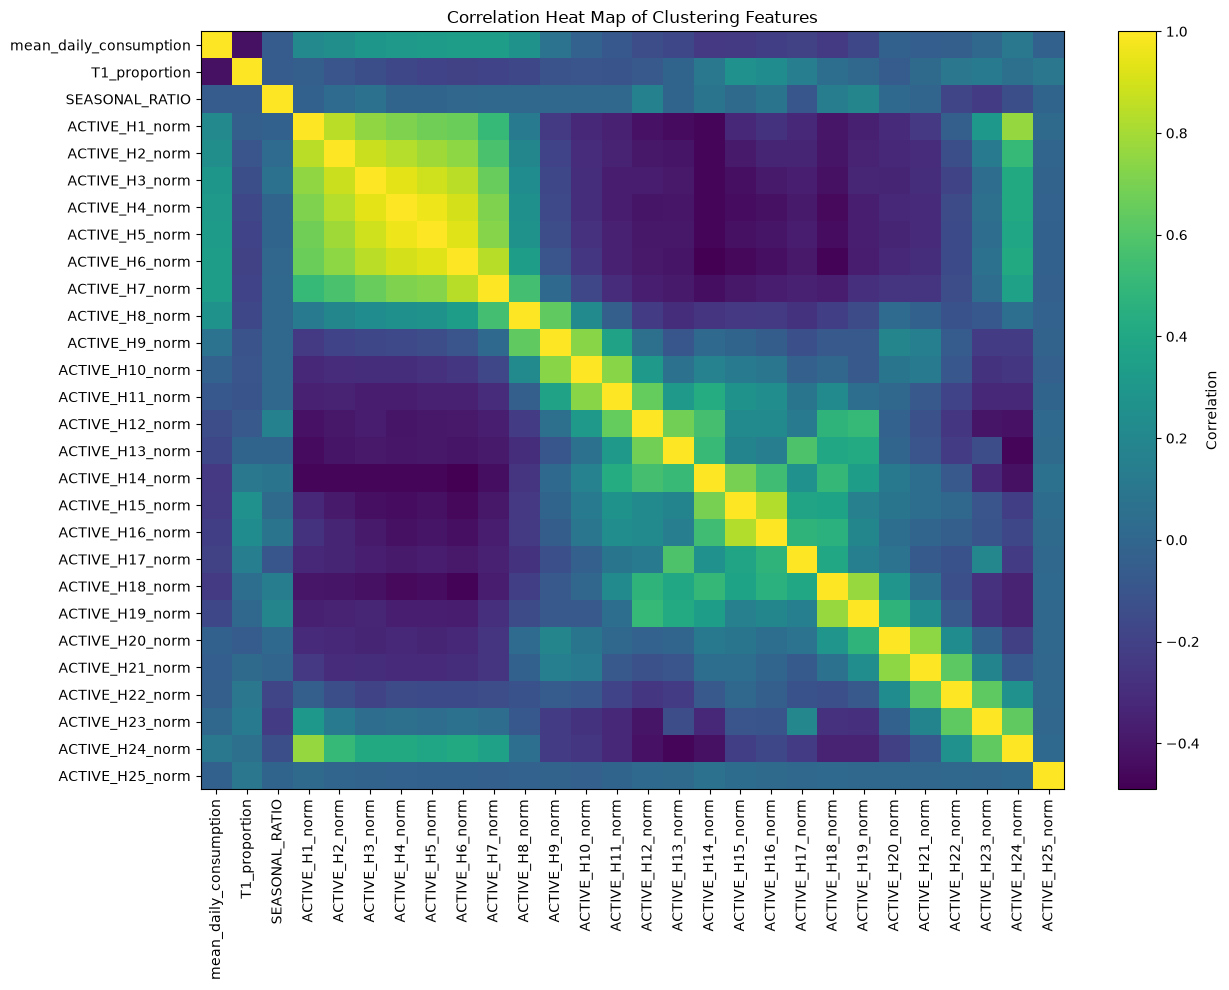

In [74]:
corr_df = df_cluster.corr()

plt.figure(figsize=(13, 10))
plt.imshow(
    corr_df.to_numpy(),
    aspect="auto",
    interpolation="nearest"
)
plt.xticks(
    range(len(corr_df.columns)),
    corr_df.columns,
    rotation=90
)
plt.yticks(
    range(len(corr_df.columns)),
    corr_df.columns
)
plt.colorbar(label="Correlation")
plt.title("Correlation Heat Map of Clustering Features")
plt.tight_layout()
plt.show()

## Clustering

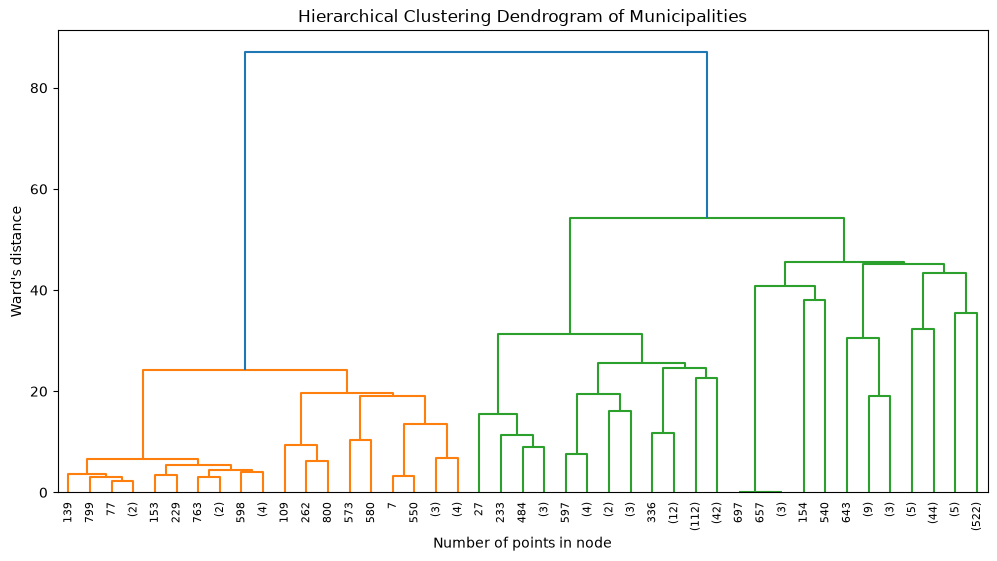

In [75]:
# 4. Scale and Cluster
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram of Municipalities")
plt.xlabel("Number of points in node")
plt.ylabel("Ward's distance")
plt.show()

In [76]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

In [77]:
muni_coords = (
    A.select(["MUNICIPALITY", "LATITUDE", "LONGITUDE", "PROVINCE"])
     .unique()
     .collect()
     .to_pandas()
     .set_index("MUNICIPALITY")
)

df_map = df_cluster.join(muni_coords, how="left")
df_map = df_map.dropna(subset=["LATITUDE", "LONGITUDE"])

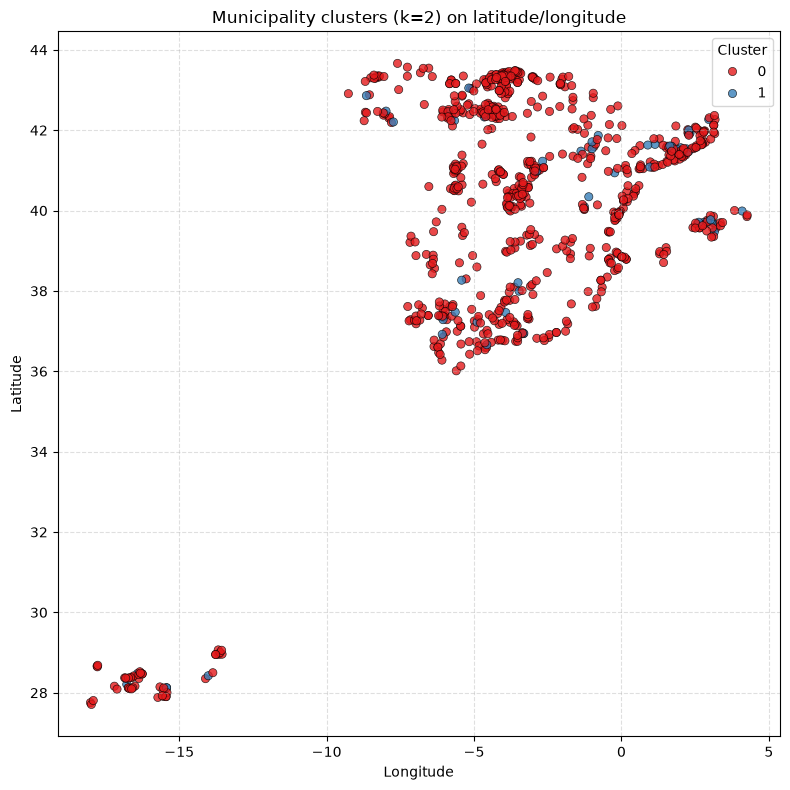

In [78]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=df_map,
    x="LONGITUDE",
    y="LATITUDE",
    hue="cluster",
    palette="Set1",
    s=35,
    edgecolor="k",
    alpha=0.8
)
plt.title("Municipality clusters (k=2) on latitude/longitude")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [79]:
from scipy.stats import mannwhitneyu

c0 = df_map.loc[df_map["cluster"] == 0, "LATITUDE"]
c1 = df_map.loc[df_map["cluster"] == 1, "LATITUDE"]

print(mannwhitneyu(c0, c1, alternative="two-sided"))

MannwhitneyuResult(statistic=np.float64(22776.5), pvalue=np.float64(0.3073477257310222))
